In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from typing import Tuple, List, Optional
from tqdm import tqdm 
from einops import rearrange, repeat, reduce, einsum
import os
import json
import mdtraj as md
import openmm.unit as unit
from boltz.lutils.cvs import Chignolin

In [3]:
from openmm import Platform
try:
    Platform.getPlatformByName('CUDA')
    print("Using CUDA platform.")
except Exception as e:
    print("CUDA platform not found. Using CPU.")
    os.environ["OPENMM_DEFAULT_PLATFORM"] = "CPU"

Using CUDA platform.


In [4]:
cvs_array = []
logp_array = []
# with open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_centers_10000mc/likelihoods.json") as f:
with open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_centers/likelihoods.json") as f:
    likelihood_dict = json.load(f)
    for pdb_path in likelihood_dict:
        traj = md.load(pdb_path)
        cvs = Chignolin(traj.topology)
        coords = torch.tensor(traj.xyz[0])
        likelihood_dict[pdb_path]["cvs"] = cvs(coords)
        cvs_array.append(likelihood_dict[pdb_path]["cvs"].cpu().numpy())
        logp_array.append(likelihood_dict[pdb_path]["logp"])

cvs_array = np.array(cvs_array)
logp_array = np.array(logp_array)
logp_array -= logp_array.min()
energy = -unit.BOLTZMANN_CONSTANT_kB * 300 * unit.kelvin * unit.AVOGADRO_CONSTANT_NA * logp_array
energy = energy.value_in_unit(unit.kilojoule_per_mole)
energy -= energy.min()  

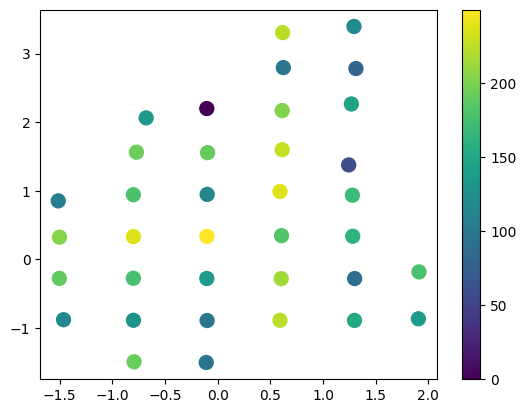

In [45]:
fig, ax = plt.subplots()
scatter = ax.scatter(cvs_array[:, 0], cvs_array[:, 1], c=logp_array, cmap='viridis', s=100)
cb = plt.colorbar(scatter)



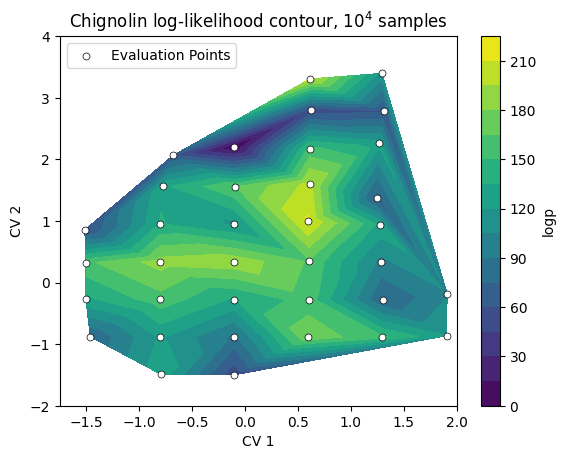

In [71]:
fig, ax = plt.subplots()
# Contour plot for scattered data
contour = ax.tricontourf(cvs_array[:, 0], cvs_array[:, 1], logp_array, levels=14, cmap='viridis')
ax.scatter(cvs_array[:, 0], cvs_array[:, 1], color='white', s=25, alpha=1, edgecolors='black', linewidths=0.5, label="Evaluation Points")  # Overlay points
cb = plt.colorbar(contour, ax=ax)
cb.set_label('logp')

ax.set(xlabel='CV 1', ylabel='CV 2', xlim=(-1.75,2), ylim=(-2,4), title=r'Chignolin log-likelihood contour, $10^4$ samples')
ax.legend(loc='upper left')
plt.show()

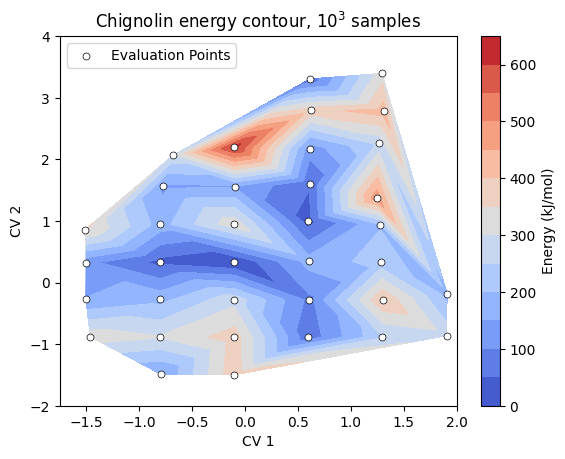

In [6]:
fig, ax = plt.subplots()
# Contour plot for scattered data
contour = ax.tricontourf(cvs_array[:, 0], cvs_array[:, 1], energy, levels=14, cmap='coolwarm')
ax.scatter(cvs_array[:, 0], cvs_array[:, 1], color='white', s=25, alpha=1, edgecolors='black', linewidths=0.5, label="Evaluation Points")  # Overlay points
cb = plt.colorbar(contour, ax=ax)
cb.set_label('Energy (kJ/mol)')

ax.set(xlabel='CV 1', ylabel='CV 2', xlim=(-1.75,2), ylim=(-2,4), title=r'Chignolin energy contour, $10^3$ samples')
ax.legend(loc='upper left')
plt.show()

In [ ]:
results_1 = json.load(open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips1/likelihoods.json", "r"))
results_2 = json.load(open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips2/likelihoods.json", "r"))
results_3 = json.load(open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips3/likelihoods.json", "r"))
results_4 = json.load(open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips4/likelihoods.json", "r"))
results_5 = json.load(open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips5/likelihoods.json", "r"))
results_ov_42 = json.load(open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips_overload_42/likelihoods.json", "r"))
results_ov_43 = json.load(open("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips_overload_43/likelihoods.json", "r"))

key_list = results_1.keys()

logps_1 = torch.tensor([results_1[r]['logp'] for r in key_list])
logps_1 = logps_1 - logps_1[0] # only look at relative logps
logps_2 = torch.tensor([results_2[r]['logp'] for r in key_list])
logps_2 = logps_2 - logps_2[0] # only look at relative logps
logps_3 = torch.tensor([results_3[r]['logp'] for r in key_list])
logps_3 = logps_3 - logps_3[0] # only look at relative logps
logps_4 = torch.tensor([results_4[r]['logp'] for r in key_list])
logps_4 = logps_4 - logps_4[0]
logps_5 = torch.tensor([results_5[r]['logp'] for r in key_list])
logps_5 = logps_5 - logps_5[0]
logps_ov_42 = torch.tensor([results_ov_42[r]['logp'] for r in key_list])
logps_ov_42 = logps_ov_42 - logps_ov_42[0]
logps_ov_43 = torch.tensor([results_ov_43[r]['logp'] for r in key_list])
logps_ov_43 = logps_ov_43 - logps_ov_43[0]

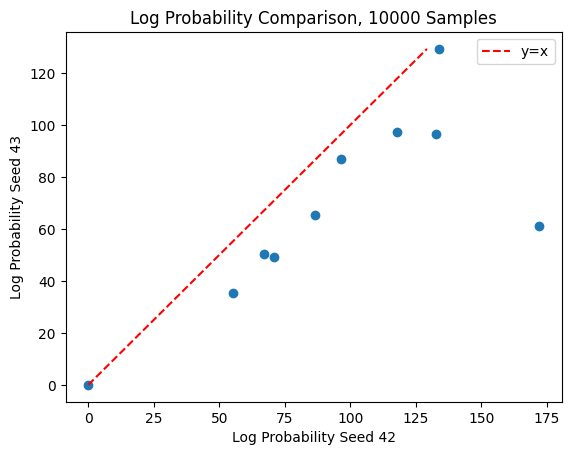

In [12]:
fig, ax = plt.subplots()
# ax.scatter(logps_ov_42, logps_ov_43)
ax.scatter(logps_ov_42, logps_5)
ax.set(xlabel='Log Probability Seed 42', ylabel='Log Probability Seed 43', title='Log Probability Comparison, 10000 Samples')
maxval = max(logps_4.max(), logps_5.max())
ax.plot([0, maxval], [0, maxval], color='red', linestyle='--', label='y=x')
ax.legend()
plt.show()

In [14]:

def euler_maruyama(f, g, x0, t_span, n_steps, forward=True, seed=None):
    """
    Euler-Maruyama integrator for SDEs of the form:
    dX_t = f(X_t, t)dt + g(X_t, t)dW_t
    
    Parameters:
    -----------
    f : callable
        Drift function f(x, t)
    g : callable  
        Diffusion function g(x, t)
    x0 : float
        Initial condition
    t_span : tuple
        Time span (t_start, t_end)
    dt : float
        Time step size
    forward : bool, optional
        If True, integrates forward in time; if False, backward in time. t_start < t_end always, if forward is False the integration is done from t_end to t_start.
    n_steps : int
        Number of time steps to take
    seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    t : ndarray
        Time points
    x : ndarray
        Solution values
    """
    if seed is not None:
        torch.random.seed(seed)
    t_start, t_end = t_span
    dt = torch.tensor((t_end - t_start) / n_steps, dtype=torch.float32)
    t = torch.linspace(t_start, t_end, n_steps, dtype=torch.float32)
    n_steps = len(t)
    
    # Generate Brownian motion increments
    dW = torch.randn((n_steps - 1,) + x0.shape, dtype=torch.float32) * torch.sqrt(dt)

    # Initialize trajectory list and add initial condition
    traj_list = [x0]

    # Euler-Maruyama iteration
    x_current = x0
    for i in range(n_steps - 1):
        t_curr = t[i] if forward else t[n_steps - 1 - i]
        x_next = x_current + f(x_current, t_curr) * dt + g(x_current, t_curr) * dW[i]
        traj_list.append(x_next)
        x_current = x_next
    
    # Stack into tensor
    traj = torch.stack(traj_list, dim=-1)

    return t, traj

reverse_time_em = lambda f, g, score, x0, t_span, n_steps, seed=None: euler_maruyama(
    lambda x, t: -f(x, t) + g(x, t)**2 * score(x, t),
    lambda x, t: g(x, t),
    x0,
    t_span,
    n_steps,
    forward=False,
    seed=seed, 
)

In [15]:
drift = lambda x, t: torch.zeros_like(x)
diffusion = lambda x, t: (2*t).sqrt()

t, traj = euler_maruyama(
    drift,
    diffusion,
    x0=torch.tensor([0.0, 0.0]),
    t_span=(0, 1),
    n_steps=100,
)

In [16]:
batch_em = torch.vmap(euler_maruyama, in_dims=(None, None, 0, None, None), out_dims=(None, 0), randomness="different")
batch_reverse_time_em = torch.vmap(reverse_time_em, in_dims=(None, None, None, 0, None, None), out_dims=(None, 0), randomness="different")
t, traj = batch_em(drift, diffusion, torch.zeros(1000,2), (0.01, 1), 200)
t_reverse, traj_reverse = batch_reverse_time_em(drift, diffusion, lambda x, t: -x / (t**2), traj[:,:,-1], (0.01, 1), 200)
bias = 1
t_reverse_approx, traj_reverse_approx = batch_reverse_time_em(drift, diffusion, lambda x, t: (-x + bias) / (t**2), traj[:,:,-1], (0.01, 1), 200)

In [5]:
print(traj_reverse[0,:,-5:])
print(traj_reverse_approx[0,:,-5:]) 

tensor([[-0.0304, -0.0002, -0.0187, -0.0016,  0.0212],
        [ 0.0209,  0.0045,  0.0006,  0.0171,  0.0154]])
tensor([[0.9882, 0.9837, 0.9944, 0.9767, 0.9943],
        [0.9961, 1.0048, 1.0083, 1.0154, 1.0235]])


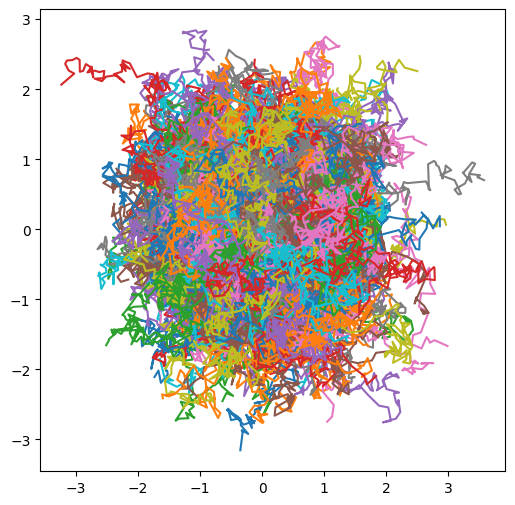

In [6]:
fig, ax = plt.subplots(figsize=(6,6))
# ax.scatter(traj[:,0], traj[:,1], label='Trajectory', c=t.numpy())
for i in range(traj.shape[0]):
    ax.plot(traj[i,0,:], traj[i,1,:], label='Trajectory')

MovieWriter Pillow unavailable; using Pillow instead.


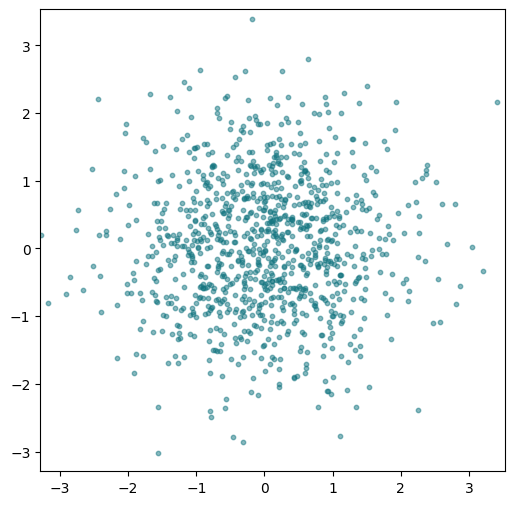

In [7]:
# make a gif that animates the trajectories
# traj is shape (batch, dim, time)
# plot a scatter for each time step

fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter([], [], s=10, alpha=0.5, c="#137580")
ax.set_xlim(traj.min().item(), traj.max().item())
ax.set_ylim(traj.min().item(), traj.max().item())
def update(frame):
    scat.set_offsets(traj[:, :, frame].numpy(), )
    return scat,
ani = animation.FuncAnimation(fig, update, frames=traj.shape[2], blit=True)
ani.save('sde_trajectories.gif', writer='Pillow', fps=20)  

MovieWriter Pillow unavailable; using Pillow instead.


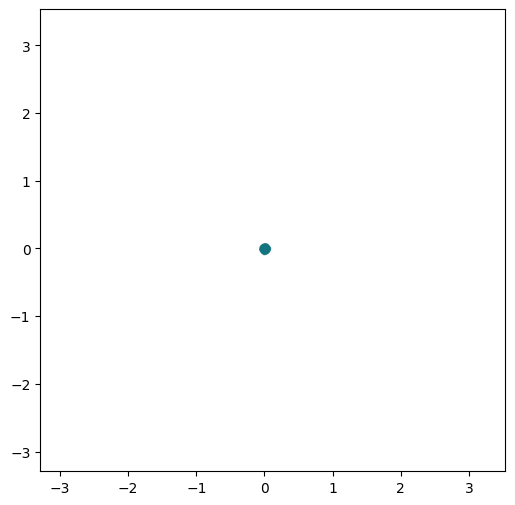

In [8]:
# make a gif that animates the trajectories first forward, then reverse time
# traj is shape (batch, dim, time)
# plot a scatter for each time step

concat_traj = torch.cat((traj, traj_reverse), dim=-1)  # Concatenate forward and reverse trajectories
fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter([], [], s=10, alpha=0.5, c="#137580")
ax.set_xlim(concat_traj.min().item(), concat_traj.max().item())
ax.set_ylim(concat_traj.min().item(), concat_traj.max().item())
def update(frame):
    scat.set_offsets(concat_traj[:, :, frame].numpy(), )
    return scat,
ani = animation.FuncAnimation(fig, update, frames=concat_traj.shape[2], blit=True)
ani.save('fwd_rev_trajectories.gif', writer='Pillow', fps=20)  

MovieWriter Pillow unavailable; using Pillow instead.


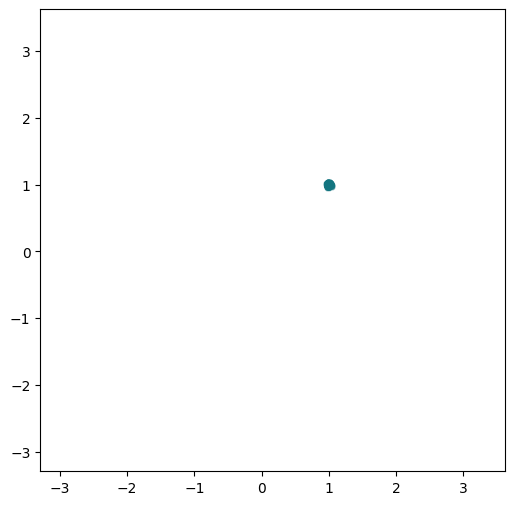

In [9]:
# make a gif that animates the trajectories first forward, then reverse time
# this time, we add a bias to the reverse time trajectory to simulate an approximate score model
# traj is shape (batch, dim, time)
# plot a scatter for each time step

concat_traj = torch.cat((traj, traj_reverse_approx), dim=-1)  # Concatenate forward and reverse trajectories
fig, ax = plt.subplots(figsize=(6,6))
scat = ax.scatter([], [], s=10, alpha=0.5, c="#137580")
ax.set_xlim(concat_traj.min().item(), concat_traj.max().item())
ax.set_ylim(concat_traj.min().item(), concat_traj.max().item())
def update(frame):
    scat.set_offsets(concat_traj[:, :, frame].numpy(), )
    return scat,
ani = animation.FuncAnimation(fig, update, frames=concat_traj.shape[2], blit=True)
ani.save('fwd_rev_approx_trajectories.gif', writer='Pillow', fps=20)  

In [10]:
center_a = torch.zeros(2)
center_b = torch.ones(2)
drift_a = lambda x, t: (center_a - x)
drift_b = lambda x, t: (center_b - x)
diffusion = lambda x, t: (2*t).sqrt()

initial_conditions = torch.rand(1000, 2)
t_a, traj_a = batch_em(drift_a, diffusion, initial_conditions, (0.01,1), 200)
t_b, traj_b = batch_em(drift_b, diffusion, initial_conditions, (0.01,1), 200)

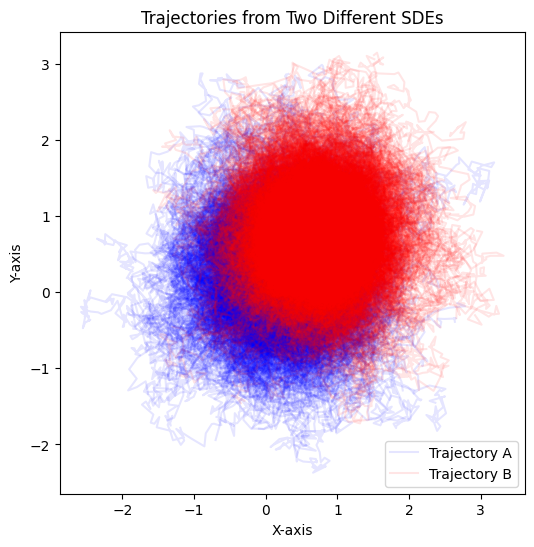

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
for i in range(traj_a.shape[0]):
    ax.plot(traj_a[i,0,:], traj_a[i,1,:], label='Trajectory A' if i==0 else None, c='blue', alpha=0.1)
for i in range(traj_b.shape[0]):
    ax.plot(traj_b[i,0,:], traj_b[i,1,:], label='Trajectory B' if i==0 else None, c='red', alpha=0.1)

ax.set_title('Trajectories from Two Different SDEs')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
plt.show()

MovieWriter Pillow unavailable; using Pillow instead.


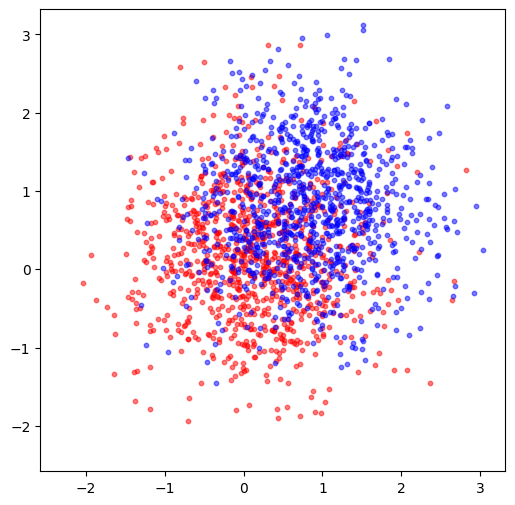

In [12]:
fig, ax = plt.subplots(figsize=(6,6))
scat_a = ax.scatter([], [], s=10, alpha=0.5, c="red")
scat_b = ax.scatter([], [], s=10, alpha=0.5, c="blue")

mins = min(traj_a.min().item(), traj_b.min().item())
maxs = max(traj_a.max().item(), traj_b.max().item())
ax.set_xlim(mins, maxs)
ax.set_ylim(mins, maxs)

def update(frame):
    scat_a.set_offsets(traj_a[:, :, frame].numpy())
    scat_b.set_offsets(traj_b[:, :, frame].numpy())
    return scat_a, scat_b

ani = animation.FuncAnimation(fig, update, frames=traj_a.shape[2], blit=True)
ani.save('sde_trajectories_a_b.gif', writer='Pillow', fps=20)

In [6]:

class ForwardReversePathEstimator:
    """
    Monte Carlo estimator for log probability differences using the 
    path integral formula derived from proper application of Itô's formula.
    """

    def __init__(self, score_model, score_div, f, g, terminal_variance, dim=2, t_start=0.01, t_end=1.0, hutchinson_samples=10):
        """
        Args:
            score_model: Neural network that outputs score function s(x,t)
            f: Drift function f(x,t)
            g: Diffusion function g(x,t)
            terminal_variance: Terminal variance for the diffusion process
            t_start: Start time for the diffusion process
            t_end: End time for the diffusion process
            hutchinson_samples: Number of samples for Hutchinson trace estimator
        """
        self.score_model = score_model
        self.f = f
        self.g = g  # Drift and diffusion functions
        self.t_start = t_start
        self.t_end = t_end
        self.hutchinson_samples = hutchinson_samples
        self.terminal_variance = terminal_variance
        self.final_dist = torch.distributions.MultivariateNormal(torch.zeros(dim), torch.eye(dim) * self.terminal_variance)
        self.score_div = score_div  # Score divergence function
        self.f_div = lambda x, t: torch.zeros_like(x).sum(-1)  # Placeholder for drift divergence

    def estimate_log_prob_difference(self,
                                   state_A: torch.Tensor,
                                   state_B: torch.Tensor,
                                   n_samples: int = 1000,
                                   n_steps: int = 100,
                                   method: str = 'forward') -> Tuple[float, float]:
        """
        Estimate log p(A) - log p(B) using the path integral.
        
        The correct formula is:
        log p_0(X_0) = log p_T(X_T) - ∫[-∇·f + g²∇·s + ½g²|s|²]dt - ∫s·g dW
        """
        log_prob_diffs = []
        x_final_A = []
        x_final_B = []

        for _ in tqdm(range(n_samples)):
            if method == 'forward':
                log_prob_A, x_f_A = self._compute_forward_path_log_prob(state_A, n_steps)
                log_prob_B, x_f_B = self._compute_forward_path_log_prob(state_B, n_steps)
            else:  # reverse
                log_prob_A = self._compute_reverse_path_log_prob(state_A, n_steps)
                log_prob_B = self._compute_reverse_path_log_prob(state_B, n_steps)

            log_prob_diffs.append(log_prob_A - log_prob_B)
            x_final_B.append(x_f_B)
            x_final_A.append(x_f_A)
        estimate = np.mean(log_prob_diffs)
        std_error = np.std(log_prob_diffs) / np.sqrt(n_samples)
        
        return estimate, std_error, torch.stack(x_final_A), torch.stack(x_final_B)
    
    def _compute_forward_path_log_prob(self, 
                                               initial_state: torch.Tensor,
                                               n_steps: int) -> float:
        """
        Compute log probability using the FORWARD path integral:

        log p_0(x_0) = log p_T(x_T) - ∫₀ᵀ [-∇·f + g²∇·s + ½g²|s|²] dt - ∫₀ᵀ s·g dW
        """
        dt = torch.tensor( (self.t_end - self.t_start) / n_steps)

        x = initial_state.clone()
        
        # Initialize path integral components
        log_prob = torch.zeros(1, dtype=torch.float32)
        stochastic_integral = torch.zeros(1, dtype=torch.float32)
        drift_integral = torch.zeros(1, dtype=torch.float32)

        # Forward diffusion path
        for step in range(1,n_steps):
            t = step * dt
            g_t = self.g(x, t)

            # Get score at current state and time
            with torch.no_grad():
                score = self.score_model(x, torch.tensor(t))
            
            # Sample noise increment
            dW = torch.randn_like(x) * np.sqrt(dt)
            
                
            drift = self.f(x, t)
            dx = drift * dt + g_t * dW
            
            # === COMPUTE ALL FOUR TERMS OF THE CORRECTED INTEGRAL ===

            div_drift = self.f_div(x, t)

            # Term 2: g²∇·s (divergence of score, expensive!)
            div_score = self._compute_score_divergence_hutchinson(x, t)
            # div_score = -2 / t**2 # true value for this specific case


            # Term 3: ½g²|s|² (score magnitude squared)
            score_mag_sq = torch.norm(score, dim=-1)**2
            
            # Term 4: s·g dW (stochastic integral increment)
            stoch_increment = torch.sum(score * g_t * dW, dim=-1)
            
            # Accumulate integrals
            drift_contrib = (-div_drift + (g_t**2 * div_score) + (0.5 * g_t**2 * score_mag_sq)) * dt
            drift_integral += drift_contrib
            stochastic_integral += stoch_increment
            
            # Update state
            x = x + dx
            assert torch.isfinite(x).all(), "State became NaN during integration"
            assert torch.isfinite(drift_integral).all(), "Drift integral became NaN during integration"
        
        # Terminal log probability: log p_T(x_T)
        terminal_log_prob = self.final_dist.log_prob(x)

        # Apply corrected formula
        log_prob = terminal_log_prob - drift_integral - stochastic_integral
        
        return log_prob, x

    # def _compute_reverse_path_log_prob(self,
    #                                            target_state: torch.Tensor,
    #                                            n_steps: int) -> float:
    #     """
    #     Compute log probability using reverse-time generation with corrected integrals.
        
    #     For reverse SDE: dX = [f - g²s] dt + g dW
    #     We integrate the path probability in reverse time.
    #     """
    #     dt = (self.t_end - self.t_start) / n_steps

    #     # Start from noise
    #     x = torch.randn_like(target_state)
        
    #     # Initial noise log probability
    #     log_prob = -0.5 * torch.sum(x**2).item() - 0.5 * x.numel() * np.log(2 * np.pi)
        
    #     # Integrals for reverse process
    #     drift_integral = 0.0
    #     stochastic_integral = 0.0
        
    #     # Reverse SDE integration
    #     for step in range(n_steps):
    #         t = self.t_end - step * dt  # Reverse time
    #         beta_t = self.beta(t)
    #         g_t = np.sqrt(beta_t)
            
    #         with torch.no_grad():
    #             score = self.score_model(x, torch.tensor(t))
            
    #         # Reverse SDE: dX = [f(X,t) - g²(t)s(X,t)] dt + g(t) dW
    #         drift_original = -0.5 * beta_t * x  # Original forward drift
    #         drift_correction = -g_t**2 * score   # Score-based correction
    #         total_drift = drift_original + drift_correction
            
    #         # Sample noise
    #         dW = torch.randn_like(x) * np.sqrt(dt)
    #         dx = total_drift * dt + g_t * dW
            
    #         # === CORRECTED PATH INTEGRAL FOR REVERSE PROCESS ===
            
    #         # The reverse process has modified dynamics, so we need to account
    #         # for the path probability under the reverse SDE
            
    #         # Divergence of modified drift: ∇·[f - g²s]
    #         div_original_drift = -0.5 * beta_t * x.numel()
    #         div_score_term = self._compute_score_divergence_hutchinson(x, t)
    #         div_total_drift = div_original_drift - g_t**2 * div_score_term
            
    #         # Score magnitude for reverse process
    #         score_mag_sq = torch.sum(score * score).item()
            
    #         # Stochastic integral
    #         stoch_increment = torch.sum(score * g_t * dW).item()
            
    #         # Accumulate (note: signs may differ for reverse integration)
    #         drift_contrib = (-div_total_drift + 0.5 * g_t**2 * score_mag_sq) * dt
    #         drift_integral += drift_contrib
    #         stochastic_integral += stoch_increment
            
    #         # Update state
    #         x = x + dx
        
    #     # Penalty for distance from target (for conditional generation)
    #     # target_penalty = 0.5 * torch.sum((x - target_state)**2).item()
    #     target_penalty = 0
        
    #     # Apply corrected reverse formula
    #     log_prob = log_prob - drift_integral - stochastic_integral - target_penalty
        
    #     return log_prob
    
    def _compute_score_divergence_hutchinson(self, x: torch.Tensor, t: float) -> float:
        """
        Compute ∇·s(x,t) using Hutchinson's trace estimator.
        
        This is the expensive operation that makes exact path integrals costly.
        ∇·s ≈ E[ε^T ∇_x(s(x,t)·ε)] where ε ~ N(0,I)
        """
        if self.score_div is not None:
            return self.score_div(x, t)
        x_copy = x.clone().requires_grad_(True)
        
        divergence_estimate = 0.0
        
        for _ in range(self.hutchinson_samples):
            # Sample random vector
            epsilon = torch.randn_like(x)
            
            # Compute score
            score = self.score_model(x_copy, torch.tensor(t))
            
            # Compute s·ε
            score_dot_eps = torch.sum(score * epsilon)
            
            # Compute gradient ∇_x(s·ε)
            grad = torch.autograd.grad(score_dot_eps, x_copy, retain_graph=True)[0]
            
            # Compute ε^T ∇_x(s·ε)
            divergence_estimate += torch.sum(epsilon * grad).item()
            assert torch.isfinite(grad).all(), "grad estimate became NaN during computation"
        
        return divergence_estimate / self.hutchinson_samples
    


In [7]:
point_A = torch.tensor([0.1, 0.1])
point_B = torch.tensor([1.0, 1.0])

# f(x,t) = 0 and g(x,t) = sqrt(2*t) for Karras
# true p(x,t) = N(x; mu_t, 1 + sigma_t^2 I)
score_model = lambda x, t: -x /(1 + t**2)
score_div = lambda x, t: -2 / (1 + t**2)  # True divergence for this specific case (set to None if you want to use Hutchinson)
f = lambda x, t: torch.zeros_like(x)
g = lambda x, t: (2*t).sqrt()


t_start = 0.001
t_end = 10.0

est = ForwardReversePathEstimator(score_model, score_div, f, g, terminal_variance=t_end**2, t_start=t_start, t_end=t_end, hutchinson_samples=100)
# Estimate log p(point_A) - log p(point_B)
estimate, std_error, x_final_A, x_final_B = est.estimate_log_prob_difference(point_A, point_B, n_samples=500, n_steps=100, method='forward')

  0%|          | 0/500 [00:00<?, ?it/s]

/tmp/ipykernel_1563084/2063906790.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  score = self.score_model(x, torch.tensor(t))
100%|██████████| 500/500 [00:11<00:00, 45.13it/s]


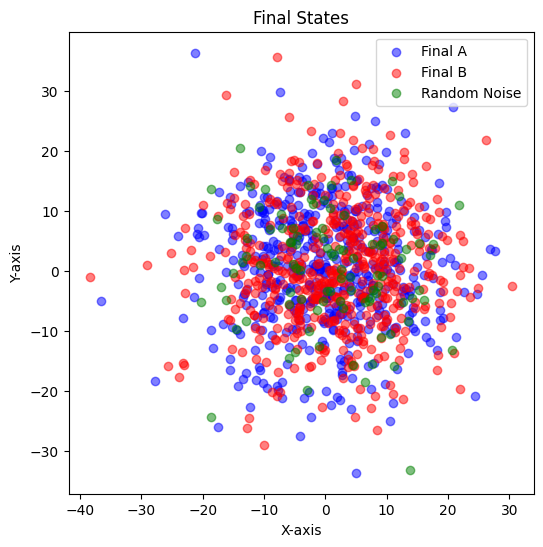

In [8]:
fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(x_final_A[:, 0].numpy(), x_final_A[:, 1].numpy(), label='Final A', c='blue', alpha=0.5)
ax.scatter(x_final_B[:, 0].numpy(), x_final_B[:, 1].numpy(), label='Final B', c='red', alpha=0.5)
ax.scatter(*torch.randn(2,100)*10, label='Random Noise', c='green', alpha=0.5)
ax.set_title(f'Final States')
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.legend()
plt.show()

In [9]:
true_dist = torch.distributions.MultivariateNormal(torch.zeros(2), torch.eye(2))
true_log_prob_A = true_dist.log_prob(point_A)
true_log_prob_B = true_dist.log_prob(point_B)

print(f"Estimated log p(A) - log p(B): {estimate:.4f} ± {std_error:.4f}")
print(f"True log p(A): {true_log_prob_A:.4f}, True log p(B): {true_log_prob_B:.4f}")
print(f"True difference: {true_log_prob_A - true_log_prob_B:.4f}")

Estimated log p(A) - log p(B): 1.0244 ± 0.0332
True log p(A): -1.8479, True log p(B): -2.8379
True difference: 0.9900


In [19]:
# calculate the path measure for a given trajectory in reverse time using the Onsager-Machlup formula
# this will allow us to weight how likely forward trajectories are in reverse time using our approximate
# reverse path learned by the score model

def log_path_measure_forward_time(forward_trajectory, timesteps, f, g, dim):
    """
    Calculate the path measure for a given forward trajectory in forward time using the Onsager-Machlup formula.
    
    Args:
        forward_trajectory: Tensor of shape (batch, dim, timesteps) representing the forward trajectory.
        timesteps: Tensor of shape (timesteps) Time points corresponding to the trajectory.
        score_model: Neural network that outputs score function s(x,t).
        f: Drift function f(x,t).
        g: Diffusion function g(x,t).
        t_start: Start time for the diffusion process.
        t_end: End time for the diffusion process.
        n_steps: Number of steps in the trajectory.
    """
    # Reverse time parameters

    # Initialize path measure
    log_p = torch.zeros(forward_trajectory.shape[0], dtype=torch.float32)

    # Iterate over time points
    for i in range(len(timesteps) - 1, 0, -1):
        t = timesteps[i]
        dt = timesteps[i] - timesteps[i-1]

        curr_x = forward_trajectory[:, :, i]
        prev_x = forward_trajectory[:, :, i-1]
        # Get the score function

        # Compute the drift and diffusion
        drift = f(curr_x, t)
        diffusion = g(curr_x, t)

        # Update the path measure using the Onsager-Machlup formula
        # log_p += -dim/2 * torch.log(2 * np.pi * dt * diffusion**2) # gaussian normalization term (can exclude for computing log ratios)
        log_p -= (1 / (2 * dt * diffusion**2)) * torch.norm(curr_x - prev_x - (drift * dt), dim=-1)**2  # quadratic term

    return log_p


def log_path_measure_reverse_time(forward_trajectory, timesteps, score_model, f, g, dim):
    """Calculate path measure under reverse-time dynamics"""
    log_p = torch.zeros(forward_trajectory.shape[0], dtype=torch.float32)
    
    # Iterate backwards through the forward trajectory
    for i in range(len(timesteps) - 1):
        t = timesteps[-(i+1)]  # Current time (going backwards)
        dt = timesteps[1] - timesteps[0]  # Keep positive dt
        
        # States: current (later in forward time) and next (earlier in forward time)
        curr_x = forward_trajectory[:, :, -(i+1)]
        next_x = forward_trajectory[:, :, -(i+2)] if i < len(timesteps) - 2 else forward_trajectory[:, :, 0]
        
        # Reverse-time drift: f - g²s
        score = score_model(curr_x, t)
        drift = f(curr_x, t)
        diffusion = g(curr_x, t)
        reverse_drift = drift - (diffusion**2 * score)
        
        # Expected displacement under reverse dynamics (going backwards in time)
        expected_displacement = -reverse_drift * dt  # Negative because we're going backwards
        
        # Actual displacement (from later to earlier state)
        actual_displacement = next_x - curr_x
        
        # Onsager-Machlup formula
        # log_p -= dim/2 * torch.log(2 * np.pi * dt * diffusion**2) # gaussian normalization term (can exclude for computing log ratios)
        log_p -= (1 / (2 * dt * diffusion**2)) * torch.norm(actual_displacement - expected_displacement, dim=-1)**2
        
    return log_p

In [20]:
# f(x,t) = 0 and g(x,t) = sqrt(2*t) for Karras
# true p(x,t) = N(x; mu_t, 1 + sigma_t^2 I)
exact_score = lambda x, t: -x /(1 + t**2) 
f = lambda x, t: torch.zeros_like(x)
g = lambda x, t: (2*t).sqrt()

timesteps, forward_trajectory = batch_em(f, g, torch.zeros(10,2), (0.01,1), 200)
reverse_trajectory = torch.flip(forward_trajectory, dims=[-1]).clone()  # Reverse the trajectory in time

print(log_path_measure_reverse_time(forward_trajectory, timesteps, exact_score, f, g, 2))
print(log_path_measure_reverse_time(reverse_trajectory, timesteps, exact_score, f, g, 2))

print(log_path_measure_forward_time(forward_trajectory, timesteps, f, g, 2))
print(log_path_measure_forward_time(reverse_trajectory, timesteps, f, g, 2))

tensor([-207.8835, -193.9767, -225.0464, -165.0296, -222.6832, -217.9162,
        -186.1045, -203.9163, -169.4747, -183.5578])
tensor([-486.0661, -765.6025, -843.1884, -682.4980, -806.8623, -969.5688,
        -684.4843, -676.3253, -530.1579, -583.7350])
tensor([-208.7048, -194.8358, -225.9573, -165.6603, -224.3295, -218.8594,
        -187.1254, -204.7107, -170.2837, -184.3179])
tensor([-486.7028, -766.0529, -844.0092, -683.1623, -806.2179, -970.1829,
        -684.6090, -677.0285, -530.4758, -584.3157])


In [33]:
# f(x,t) = 0 and g(x,t) = sqrt(2*t) for Karras
# true p(x,t) = N(x; mu_t, 1 + sigma_t^2 I)
bias = 1.0
t_start = 0.00
variance_start = 1.0
t_end = 10.0
num_samples = 10000
num_timepoints = 200

true_score = lambda x, t: (-x) /(variance_start + t**2)  # add a small bias to the score to represent an approximate score model
approximate_score = lambda x, t: 1.2 * (-x + bias) /(variance_start + t**2)  # add a small bias to the score to represent an approximate score model
f = lambda x, t: torch.zeros_like(x)
g = lambda x, t: (2*t).sqrt()

timesteps, forward_trajectory = batch_em(f, g, variance_start * torch.randn(num_samples, 2), (t_start, t_end), num_timepoints)
timesteps_reverse, reverse_trajectory = batch_reverse_time_em(f, g, true_score, forward_trajectory[:,:,-1], (t_start, t_end), num_timepoints)
t_reverse, model_reverse_time_trajectory = batch_reverse_time_em(f, g, approximate_score, forward_trajectory[:,:,-1], (t_start, t_end), num_timepoints)


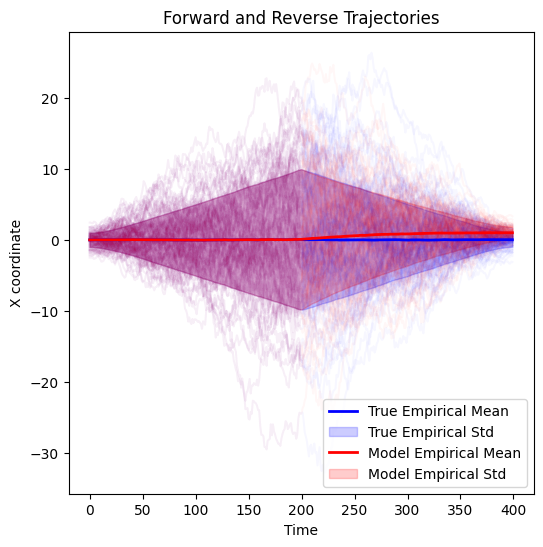

Start Mean True: -0.01, Start Std True: 1.01
Start Mean Model: -0.01, Start Std Model: 1.01
Midpoint Mean True: 0.05, Midpoint Std True: 9.88
Midpoint Mean Model: 0.05, Midpoint Std Model: 9.88
Final Mean True: 0.01, Final Std True: 1.00
Final Mean Model: 0.98, Final Std Model: 0.85


In [34]:
max_num_traces = 100
concat_correct_reversal = torch.cat((forward_trajectory, reverse_trajectory), dim=-1)  # Concatenate forward and reverse trajectories
empirical_mean_true = torch.mean(concat_correct_reversal, dim=0)
empirical_std_true = torch.std(concat_correct_reversal, dim=0)
concat_model_reversal = torch.cat((forward_trajectory, model_reverse_time_trajectory), dim=-1) 
empirical_mean_model = torch.mean(concat_model_reversal, dim=0)
empirical_std_model = torch.std(concat_model_reversal, dim=0)

fig, ax = plt.subplots(figsize=(6,6))

ax.plot(concat_correct_reversal[:max_num_traces,0,:].T, c='blue', alpha=3/max_num_traces)
ax.plot(concat_model_reversal[:max_num_traces,0,:].T, c='red', alpha=3/max_num_traces)
ax.plot(empirical_mean_true[0,:], label='True Empirical Mean', c='blue', linewidth=2)
ax.fill_between(torch.arange(empirical_mean_true.shape[1]), 
                empirical_mean_true[0,:] - empirical_std_true[0,:], 
                empirical_mean_true[0,:] + empirical_std_true[0,:], 
                color='blue', alpha=0.2, label='True Empirical Std')
ax.plot(empirical_mean_model[0,:], label='Model Empirical Mean', c='red', linewidth=2)
ax.fill_between(torch.arange(empirical_mean_model.shape[1]), 
                empirical_mean_model[0,:] - empirical_std_model[0,:], 
                empirical_mean_model[0,:] + empirical_std_model[0,:], 
                color='red', alpha=0.2, label='Model Empirical Std')
ax.set(title='Forward and Reverse Trajectories', xlabel='Time', ylabel='X coordinate')
ax.legend()
plt.show()



print(f"Start Mean True: {empirical_mean_true[0,0].item():.2f}, Start Std True: {empirical_std_true[0,0].item():.2f}")
print(f"Start Mean Model: {empirical_mean_model[0,0].item():.2f}, Start Std Model: {empirical_std_model[0,0].item():.2f}")
midpoint_index = empirical_mean_true.shape[1] // 2
print(f"Midpoint Mean True: {empirical_mean_true[0,midpoint_index].item():.2f}, Midpoint Std True: {empirical_std_true[0,midpoint_index].item():.2f}")
print(f"Midpoint Mean Model: {empirical_mean_model[0,midpoint_index].item():.2f}, Midpoint Std Model: {empirical_std_model[0,midpoint_index].item():.2f}")
print(f"Final Mean True: {empirical_mean_true[0,-1].item():.2f}, Final Std True: {empirical_std_true[0,-1].item():.2f}")
print(f"Final Mean Model: {empirical_mean_model[0,-1].item():.2f}, Final Std Model: {empirical_std_model[0,-1].item():.2f}")




In [35]:
# We want to evaluate the likelihood of producing a sample x under the approximate score model's reverse time trajectory
# but only simulate in forward time. The strategy is to use the path measure of the forward and reverse trajectories
# to weight the likelihood of the forward trajectory under the reverse time model.
# We also want to leverage that at t_end, we know the distribution is a Gaussian with mean 0 and variance t_end^2.

def evaluate_likelihood_under_reverse_model(datapoint, f, g, score_model, dim, t_start, t_end, terminal_dist, num_simulations=1000, num_timepoints=200):
    """
    Evaluate the likelihood of producing a sample x under the approximate score model's reverse time trajectory.
    
    Args:
        datapoint: single sample tensor of shape (dim,).
        f: Drift function f(x,t).
        g: Diffusion function g(x,t).
        score_model: Neural network that outputs score function s(x,t).
        dim: Dimensionality of the state space.
        t_start: Start time for the diffusion process.
        t_end: End time for the diffusion process.
        terminal_dist: Terminal distribution at t_end, typically a Gaussian. Must have a log_prob() method.
        num_simulations: Number of simulations to run.
        num_timepoints: Number of time points to simulate the trajectory.
    """
    timesteps, forward_trajectory = batch_em(f, g, datapoint.repeat(num_simulations, 1), (t_start, t_end), num_timepoints)

    # Calculate path measure for forward trajectory
    log_p_forward = log_path_measure_forward_time(forward_trajectory, timesteps, f, g, dim)
    
    # Calculate path measure for reverse trajectory using the approximate score model
    log_p_reverse = log_path_measure_reverse_time(forward_trajectory, timesteps, score_model, f, g, dim)
    
    # Terminal distribution at t_end is Gaussian with mean 0 and variance t_end^2
    t_end = timesteps[-1]
    
    # Evaluate likelihood at the last time point
    terminal_log_prob = terminal_dist.log_prob(forward_trajectory[:, :, -1])
    
    # Combine the log probabilities
    log_likelihood = terminal_log_prob + log_p_reverse - log_p_forward

    log_mean = reduce(log_likelihood, "b -> 1", torch.logsumexp) - torch.log(torch.tensor(num_simulations, dtype=log_likelihood.dtype, device=log_likelihood.device))
    std_error = log_likelihood.exp().std() / torch.sqrt(torch.tensor(num_simulations, dtype=log_likelihood.dtype, device=log_likelihood.device))

    log_weights_shifted = log_likelihood - log_likelihood.max()  # For numerical stability

    # ESS = (sum w_i)^2 / sum(w_i^2)
    log_sum_weights = torch.logsumexp(log_weights_shifted, dim=0)  # log(sum w_i)
    log_sum_weights_squared = torch.logsumexp(2 * log_weights_shifted, dim=0)  # log(sum w_i^2)

    log_ess = 2 * log_sum_weights - log_sum_weights_squared


    return log_mean.item(), std_error.item(), log_ess

true_generation_dist = torch.distributions.MultivariateNormal(empirical_mean_model[:,-1], torch.diag(empirical_std_model[:,-1]**2))
prior_dist = torch.distributions.MultivariateNormal(torch.zeros(2), torch.eye(2) * t_end**2)
test_point_A = torch.tensor([0.1, -2.0])
test_point_B = torch.tensor([1.0, 1.0])
estimated_logp_A, std_error_A, log_ess_A = evaluate_likelihood_under_reverse_model(
    datapoint=test_point_A, f=f, g=g, score_model=approximate_score,
    dim=2, t_start=t_start, t_end=t_end, terminal_dist=prior_dist, num_simulations=1000
)
estimated_logp_B, std_error_B, log_ess_B = evaluate_likelihood_under_reverse_model(
    datapoint=test_point_B, f=f, g=g, score_model=approximate_score,
    dim=2, t_start=t_start, t_end=t_end, terminal_dist=prior_dist, num_simulations=1000
)
estimated_logp_diff = estimated_logp_A - estimated_logp_B
true_logp_diff = true_generation_dist.log_prob(test_point_A) - true_generation_dist.log_prob(test_point_B)

print(f"Estimated log p difference under reverse model: {estimated_logp_diff:.4f}")
print(f"std error: A={std_error_A:.4f}, B={std_error_B:.4f}")
print(f"True log p difference: {true_logp_diff:.4f}")


Estimated log p difference under reverse model: -6.7840
std error: A=0.0000, B=0.0035
True log p difference: -6.5993


In [36]:
print("ESS A:", log_ess_A.exp(), "ESS B:", log_ess_B.exp())

ESS A: tensor(569.5544) ESS B: tensor(737.6985)


In [25]:
empirical_std_true[:,-1]

tensor([0.9990, 1.0102])

In [66]:
empirical_mean_model.shape

torch.Size([2, 400])

In [ ]:
import time

def calc_likelihoods_ips(
    input_coords=None,
    likelihood_args=None,
    device="cpu",
    **network_condition_kwargs,
):
    """Does monte carlo likelihood calculation using Importance Path Sampling
    
    Parameters
    ----------
    input_coords : dict
        Keys are PDB filenames, values are tensors of shape 
        (n_padded_atoms, 3)
        Processed coordinates of the input PDB(s).

    likelihood_args : dict
        atol : float
            Absolute tolerance of ODE solver.

        rtol : float
            Relative tolerance of ODE solver. 

        likelihood_mode : str
            Sets which method to use for calculating the score 
            diverence term. Options: 'jac', 'hutchinson'.

        hutchinson_samples : int
            Sets how many samples to compute and average results 
            across for Hutchinson trace estimation.

        outdir : str
            Directory to save likelihood results to.

    \\*\\*network_condition_kwargs : dict
        See AtomDiffusion.sample() docstring.

    Notes
    -----
    calc_likelihoods' sigma_min and sigma_max values are those of
    the default diffusion rollout's (ie. hardcoded, see line below).

    Effective sample size (ESS) is computed as 
    ESS = (sum w_i)^2 / sum(w_i^2), where w_i are the importance weights 
    in non-log space; this quantifies the number of independent samples 
    contributing to the estimate after weighting.
    """
    num_sampling_steps = self.num_sampling_steps # 200 by default.
    num_mc_samples = likelihood_args.get('num_mc_samples', 1000)
    sigmas = self.sample_schedule(num_sampling_steps) # goes from T_max to 0.
    print("sigmas shape:", sigmas.shape)
    results = {}

    def _score_fn_batch_reshaped(coords, sigma): 
        # takes in the coords of shape (batch, n_padded_atoms * 3),
        # reshapes it to (batch, n_padded_atoms, 3) and computes the score.
        # and then returns the score in shape (batch, n_padded_atoms * 3)
        # coords are now already on GPU
        batch_size, data_dim = coords.shape
        coords_gpu = coords.view(batch_size, -1, 3)  # Reshape to (batch_size, n_padded_atoms, 3)
        # center the coordinates to origin
        coords_gpu = coords_gpu - coords_gpu.mean(dim=1, keepdim=True)
        denoised, _ = self.preconditioned_network_forward(
            coords_gpu,  # add batch dimension
            sigma.item(),
            training=False,
            network_condition_kwargs=dict(
                multiplicity=batch_size,  # Changed from 1 to batch_size
                model_cache={},
                **network_condition_kwargs,
            ),
        )
        score = ((denoised - coords_gpu) / (sigma ** 2)) # (batch_size, n_padded_atoms, 3)
        score = score.view(batch_size, -1)  # Reshape back to (batch_size, n_padded_atoms * 3)
        return score  # Keep on GPU
    
    def forward_path_em(starting_coords, timepoints):
        """
        Evolve the sample in forward time using the Euler-Maruyama discretization.
        Also collects the path weights for importance sampling.
        Trajectory is kept on GPU for faster computation.

        Parameters
        ----------
        starting_coords : torch.tensor of shape (batch, n_padded_atoms * 3)
            Initial coordinates of the structure.

        timepoints : list of floats
            List of noise levels/time values at each time step.
            MUST be in ascending order.

        Returns
        -------
        coords_path : torch.tensor of shape (len(timepoints), batch, n_padded_atoms * 3)
            Path of coordinates at each time step (on GPU).
        log_path_weights : torch.tensor of shape (batch,)
            Logarithm of the path weights for importance sampling (on GPU).
        """
        batch_size, data_dim = starting_coords.shape # should be n_padded_atoms * 3
        # Keep trajectory on GPU for faster computation
        starting_coords_gpu = starting_coords.to(device)
        coords_path = starting_coords_gpu.new_zeros(
            (len(timepoints), batch_size, data_dim)
        )
        coords_path[0] = starting_coords_gpu
        log_path_weights = starting_coords_gpu.new_zeros((batch_size), dtype=torch.float32)
        for i in range(len(timepoints)-1):
            coords = coords_path[i]
            sigma = timepoints[i]
            if sigma == 0:
                sigma = 1e-3
            next_sigma = timepoints[i + 1]
            delta_t = next_sigma - sigma
            dW = torch.randn_like(coords_path[0]) * torch.sqrt(torch.tensor(delta_t, device=device))
            # Karras uses f = 0, g(t) = sqrt(2t) 
            # noising kernel is then dX_t = sqrt(2t) * dW_t so X_{t+dt} ~ N(X_t, 2t * dt I)

            # Clamp delta_t and sigma to avoid division by zero
            safe_delta_t = torch.clamp(torch.tensor(delta_t, device=device), min=1e-8)
            safe_sigma = torch.clamp(torch.tensor(sigma, device=device), min=1e-8)

            new_coords = coords + torch.sqrt(torch.tensor(2 * safe_sigma, device=device)) * dW
            coords_path[i + 1] = new_coords
            log_path_weights -= (1 / (4 * safe_delta_t * safe_sigma)) * torch.norm(coords - new_coords, dim=-1)**2  # quadratic term
        return coords_path, log_path_weights
    
    def log_path_measure_reverse_time(forward_trajectory, timesteps, score_model):
        """
        Calculate path measure under reverse-time dynamics
        Trajectory is on GPU for faster computation.
        
        Parameters
        ----------
        forward_trajectory : torch.tensor of shape (num_timesteps, batch, n_padded_atoms * 3)
            Trajectory in forward time (on GPU).
        
        timesteps : list of floats

        both should be in ascending order of time/sigma values

        score_model : callable (torch.tensor, float) -> torch.tensor
            Function that computes the score(x,t) at given coordinates and time.

        Returns
        log_p = torch.zeros(forward_trajectory.shape[1], dtype=forward_trajectory.dtype, device=self.device)
        log_p : torch.tensor of shape (batch,)
            Logarithm of the path measure under reverse-time dynamics (on GPU).
        """
        log_p = torch.zeros(forward_trajectory.shape[1], dtype=torch.float32, device=device)

        # Iterate backwards through the forward trajectory
        for i in range(len(timesteps) - 1):
            t = timesteps[-(i+1)]  # Current time (going backwards)
            delta_t = timesteps[-(i+1)] - timesteps[-(i+2)]  # Keep positive dt

            # States: current (later in forward time) and next (earlier in forward time)
            curr_x = forward_trajectory[-(i+1), :, :]  # On GPU
            next_x = forward_trajectory[-(i+2), :, :] if i < len(timesteps) - 2 else forward_trajectory[0, :, :]  # On GPU
            
            # Reverse-time drift: f - g²s
            # score_model now works with GPU tensors
            score = score_model(curr_x, t)  # Returns result on GPU
            diffusion_sq = 2 * t
            reverse_drift = - (diffusion_sq * score)
            
            # Expected displacement under reverse dynamics (going backwards in time)
            expected_displacement = -reverse_drift * delta_t  # Negative because we're going backwards
            
            # Actual displacement (from later to earlier state)
            actual_displacement = next_x - curr_x
            
            # Onsager-Machlup formula
            log_p -= (1 / (2 * delta_t * diffusion_sq)) * torch.norm(actual_displacement - expected_displacement, dim=-1)**2
            
        return log_p

    runtimes = []
    for pdb_name, struct in tqdm(
        input_coords.items(),
        desc='Computing likelihoods for all provided structures',
        mininterval=10
    ):
        start_time = time.time()
        struct.requires_grad_()
        n_padded_atoms = len(struct)
        
        sigma_min, sigma_max = sigmas[-2], sigmas[0] # Last sigma is 0.
        t = struct.new_tensor([sigma_min, sigma_max])
        x_min = struct.view(1, -1).to(device)  # Reshape to (1, n_padded_atoms * 3) and move to GPU
        x_min = x_min.repeat(num_mc_samples, 1)  # Repeat for number of MC samples

        ascending_time = torch.flip(sigmas.clone(), dims=[0])  # Keep time on same device as sigmas
        x_path, log_path_weights_fwd = forward_path_em(
            x_min,
            ascending_time
        )

        log_path_weights_rev = log_path_measure_reverse_time(
            x_path,
            ascending_time,
            _score_fn_batch_reshaped
        )

        latent = x_path[-1]  # Last step in the forward path (on GPU)

        # ll_prior = torch.distributions.Normal(0, sigma_max.cpu()).log_prob(latent.flatten()).sum()
        ll_prior = torch.distributions.MultivariateNormal(torch.zeros(latent.shape[-1], device=device), sigma_max**2 * torch.eye(latent.shape[-1], device=device)).log_prob(latent)

        # take the average in non-log space
        # All tensors are on GPU now
        log_likelihoods = log_path_weights_rev + ll_prior - log_path_weights_fwd
        log_mean_likelihood = torch.logsumexp(log_likelihoods, dim=0) - torch.log(torch.tensor(num_mc_samples, dtype=torch.float32, device=device))

        # normalized_log_weights = log_likelihoods - torch.logsumexp(log_likelihoods, dim=0)  # Normalize log weights
        # log_effective_sample_size = -torch.logsumexp(2 * normalized_log_weights, dim=0)  # log(1/sum(w_i^2)) = -logsumexp(2 log(w_i))

        log_weights_shifted = log_likelihoods - log_likelihoods.max()  # For numerical stability

        # ESS = (sum w_i)^2 / sum(w_i^2)
        log_sum_weights = torch.logsumexp(log_weights_shifted, dim=0)  # log(sum w_i)
        log_sum_weights_squared = torch.logsumexp(2 * log_weights_shifted, dim=0)  # log(sum w_i^2)

        log_ess = 2 * log_sum_weights - log_sum_weights_squared

        results[pdb_name] = {"logp": log_mean_likelihood.item(),
                                "effective_sample_size": log_ess.exp().item(),
                                "num_mc_samples": num_mc_samples}
        endtime = time.time()
        runtimes.append(endtime - start_time)
        print(f'{pdb_name} took  {endtime - start_time:.2f} seconds')


In [12]:
# instantiate a runtime by loading the correct args
input_coords=torch.load("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips/input_coords.pth", weights_only=False)
network_condition_kwargs=torch.load("/global/homes/d/dunne/boltz-likelihoods/boltz_results_chignolin_ll_test_ips/network_condition_kwargs.pth", weights_only=False),

In [ ]:
calc_likelihoods_ips(
                s_trunk=network_condition_kwargs[0]["s_trunk"],
                z_trunk=network_condition_kwargs[0]["z_trunk"],
                s_inputs=network_condition_kwargs[0]["s_inputs"], # Pre-trunk token-level sequence.
                feats=network_condition_kwargs[0]["feats"],
                relative_position_encoding=network_condition_kwargs[0]["relative_position_encoding"],
                input_coords=input_coords,
                device="cpu"
                likelihood_args=None
)

NameError: name 'self' is not defined

In [182]:

def sample_schedule(num_sampling_steps=200, rho=7, device="cpu", sigma_min=0.0004,
    sigma_max=160.0, sigma_data=16.0):
    """AF3 diffusion noise scheduler. See pg. 24 of AF3 supps.

    Returns
    -------
    sigmas : torch.tensor of shape (num_sampling_steps, )
    """
    inv_rho = 1 / rho # 1/7 by default.

    steps = torch.arange(
        num_sampling_steps, device=device, dtype=torch.float32
    )
    sigmas = (
        sigma_max**inv_rho
        + steps
        / (num_sampling_steps - 1)
        * (sigma_min**inv_rho - sigma_max**inv_rho)
    ) ** rho

    sigmas = sigmas * sigma_data # sigma_data is 16 by default.

    sigmas = torch.nn.functional.pad(sigmas, (0, 1), value=0.0)  # last step is sigma value of 0.
    return sigmas

def forward_path_em(starting_coords, timepoints, device="cpu"):
    """
    Evolve the sample in forward time using the Euler-Maruyama discretization.
    Also collects the path weights for importance sampling.
    Trajectory is kept on GPU for faster computation.

    Parameters
    ----------
    starting_coords : torch.tensor of shape (batch, n_padded_atoms * 3)
        Initial coordinates of the structure.

    timepoints : list of floats
        List of noise levels/time values at each time step.
        MUST be in ascending order.

    Returns
    -------
    coords_path : torch.tensor of shape (len(timepoints), batch, n_padded_atoms * 3)
        Path of coordinates at each time step (on GPU).
    log_path_weights : torch.tensor of shape (batch,)
        Logarithm of the path weights for importance sampling (on GPU).
    """
    batch_size, data_dim = starting_coords.shape # should be n_padded_atoms * 3
    # Keep trajectory on GPU for faster computation
    starting_coords_gpu = starting_coords.to(device)
    coords_path = starting_coords_gpu.new_zeros(
        (len(timepoints), batch_size, data_dim)
    )
    coords_path[0] = starting_coords_gpu
    log_path_weights = starting_coords_gpu.new_zeros((batch_size), dtype=torch.float32)
    for i in range(len(timepoints)-1):
        coords = coords_path[i]
        sigma = timepoints[i]

        next_sigma = timepoints[i + 1]
        delta_t = next_sigma - sigma
        dW = torch.randn_like(coords_path[0]) * torch.sqrt(delta_t)
        # Karras uses f = 0, g(t) = sqrt(2t) 
        # noising kernel is then dX_t = sqrt(2t) * dW_t so X_{t+dt} ~ N(X_t, 2t * dt I)
        if not (torch.isclose(sigma, torch.zeros_like(sigma)) or torch.isclose(delta_t, torch.zeros_like(sigma))) :
            new_coords = coords + torch.sqrt(2 * sigma) * dW
            log_path_weights -= (1 / (4 * delta_t * sigma)) * torch.norm(coords - new_coords, dim=-1)**2  # quadratic term
        else:
            print(f"Warning: sigma={sigma}, delta_t={delta_t}")
            new_coords = coords.clone()
        coords_path[i + 1] = new_coords

    return coords_path, log_path_weights

In [184]:
num_paths = 100
starting_coords = torch.zeros(num_paths, 2)
sigmas = sample_schedule(num_sampling_steps=200, device="cpu", sigma_data=16)
ascending_time = torch.flip(sigmas.clone(), dims=[0])  
# ascending_time = ascending_time[1:] # take off 0 start
coords_path, log_path_weights = forward_path_em(starting_coords, ascending_time, device="cpu")
print(coords_path.shape)

torch.Size([201, 100, 2])


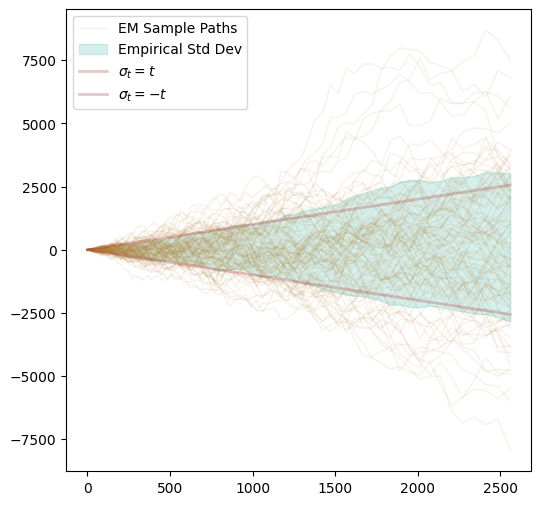

In [185]:
mean = coords_path[:, :, 0].mean(dim=1)
stdev = coords_path[:, :, 0].std(dim=1)
fig, ax = plt.subplots(figsize=(6,6))
for i in range(coords_path.shape[1]):
    ax.plot(ascending_time, coords_path[:, i, 0], color="#b07f3145", alpha=10/num_paths, linewidth=1, label="EM Sample Paths" if i==0 else None)  
    # ax.scatter(ascending_time, independent_samples[:, i, 0])
ax.fill_between(ascending_time, mean -  stdev, mean + stdev, alpha=0.2, color="#31b0a545", label='Empirical Std Dev')
ax.plot(ascending_time, ascending_time, color="#b0313145", label=r'$\sigma_t=t$', linewidth=2)

ax.plot(ascending_time, -ascending_time, color="#b0313145", label=r'$\sigma_t=-t$', linewidth=2)
ax.legend()
plt.show()

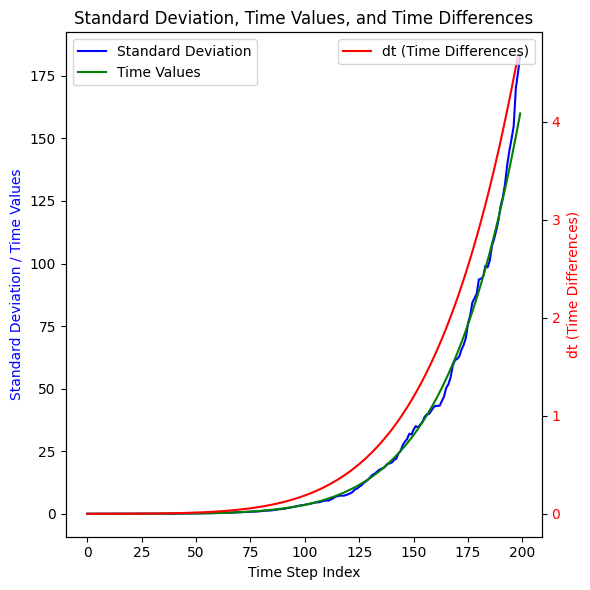

In [111]:
fig, ax = plt.subplots(figsize=(6,6))
ax.plot(stdev, label='Standard Deviation', color='blue')
ax.plot(ascending_time, label='Time Values', color='green')
ax.set_xlabel('Time Step Index')
ax.set_ylabel('Standard Deviation / Time Values', color='blue')
ax.legend(loc='upper left')

# Create second y-axis for dt
ax2 = ax.twinx()
dt = torch.diff(ascending_time)
ax2.plot(dt, color='red', label='dt (Time Differences)')
ax2.set_ylabel('dt (Time Differences)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Standard Deviation, Time Values, and Time Differences')
plt.tight_layout()